# Pipeline preditivo completo para prever quebras mecânicas em equipamentos.

In [ ]:
# Bibliotecas do projeto.

import sys

# Adiciona a raiz do projeto ao caminho de importação.
sys.path.append("../")

# Funções do projeto.

from src.carregamento import carregar_dataset

from src.analise_exploratoria import (
    inspecionar_dados,
    grafico_distribuicao_falhas,
    grafico_distribuicao_variaveis,
    grafico_correlacao
    )

from src.tratamento_dados import (
    tratar_dados,
    gerar_boxplots
)

from src.criar_feature import (criar_features)

from src.preparacao_modelo import (
    separar_variaveis,
    preparar_variaveis_categoricas,
    dividir_dados,
    aplicar_smote)


In [ ]:
#Carregamento do dataset.

df = carregar_dataset("../data/manutencao_preditiva.csv")

# Inspeção dos dados.

df.head()

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


# Análise Exploratória

In [ ]:
# Função para inspecionar os dados do dataset.

inspecionar_dados(df)


============================== Inspeção Inicial dos Dados ==============================
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      10000 non-null  int64  
 1   id_produto               10000 non-null  str    
 2   tipo                     10000 non-null  str    
 3   temperatura_ar_k         9500 non-null   float64
 4   temperatura_processo_k   9500 non-null   float64
 5   velocidade_rotacao_rpm   9500 non-null   float64
 6   torque_nm                9500 non-null   float64
 7   desgaste_ferramenta_min  10000 non-null  int64  
 8   falha_maquina            10000 non-null  int64  
 9   falha_twf                10000 non-null  int64  
 10  falha_hdf                10000 non-null  int64  
 11  falha_pwf                10000 non-null  int64  
 12  falha_osf                10000 non-null  int64  
 13

### Análise da Inspeção Inicial dos Dados

Durante a inspeção inicial foi identificado que o dataset `manutencao_preditiva.csv` possui 10.000 registros e 14 variáveis, contendo informações relacionadas às condições operacionais dos equipamentos, como temperatura, velocidade de rotação, torque e desgaste da ferramenta.

A base apresenta variáveis numéricas contínuas, variáveis inteiras e variáveis categóricas. A coluna `falha_maquina` foi definida como variável alvo binária do problema preditivo, representando a ocorrência ou não de falha no equipamento.

Também foram identificados valores ausentes nas variáveis `temperatura_ar_k`, `temperatura_processo_k`, `velocidade_rotacao_rpm` e `torque_nm`, contendo 500 registros sem informação em cada uma dessas características. Esses valores deverão ser tratados na etapa de limpeza e preparação dos dados.

A inspeção inicial também sugere uma possível concentração de registros classificados como funcionamento normal na variável alvo, sendo necessária uma análise mais detalhada do balanceamento das classes antes do treinamento dos modelos.


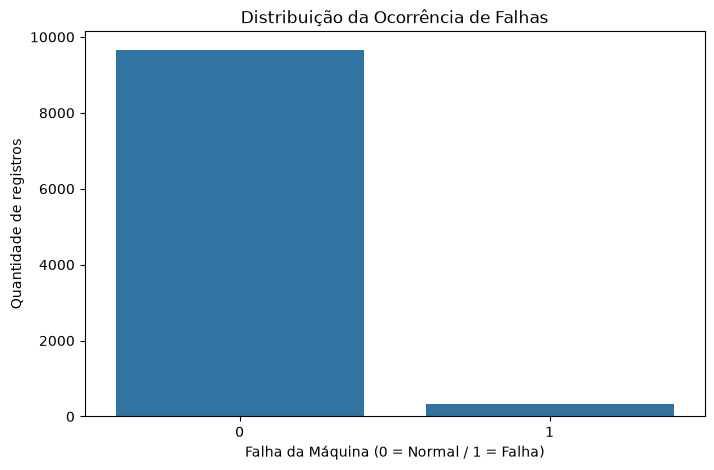

In [ ]:
# Função para gerar o gráfico de distribuição das falhas.

grafico_distribuicao_falhas(df)

### Análise da distribuição da variável alvo

O gráfico de distribuição da variável `falha_maquina` evidencia um grande desbalanceamento entre as classes.

A maior parte dos registros pertence à classe 0, representando equipamentos em funcionamento normal, enquanto uma pequena parcela pertence à classe 1, representando equipamentos com falha.


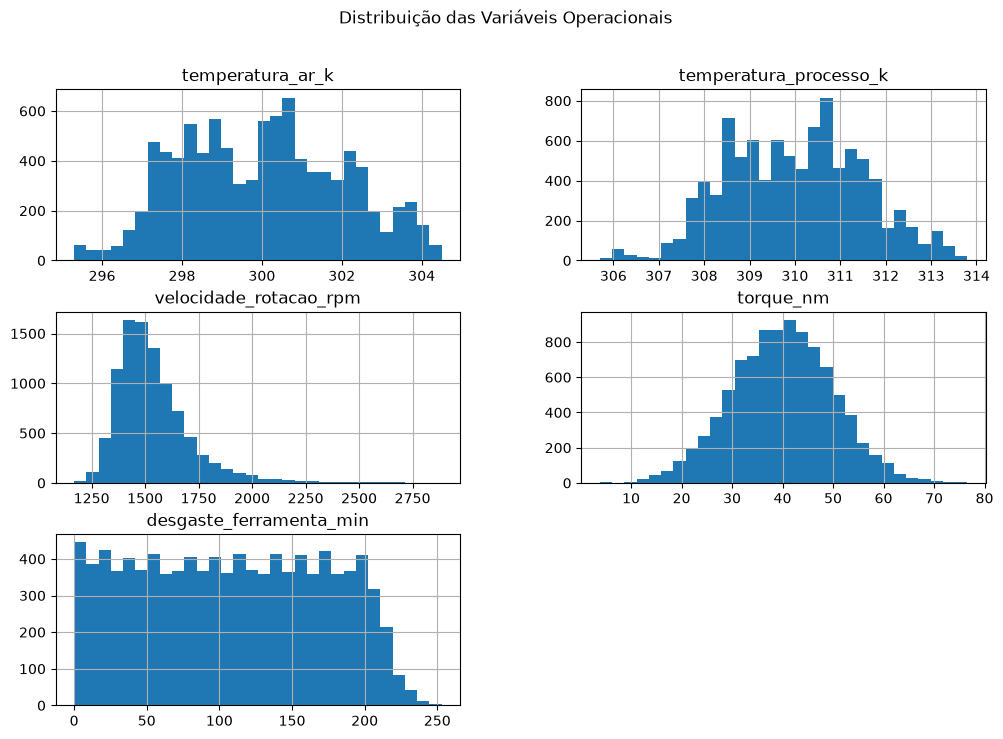

In [ ]:
#Função para gerar o gráfico de distribuição das variáveis.

grafico_distribuicao_variaveis(df)

### Análise das distribuições das variáveis operacionais

A análise dos histogramas permite observar o comportamento das principais variáveis utilizadas para caracterizar as condições operacionais dos equipamentos.

As variáveis de temperatura e torque apresentam distribuições aproximadamente simétricas, indicando uma concentração dos valores próximos à média. Já a variável velocidade_rotacao_rpm apresenta uma dispersão maior e uma cauda para valores elevados, indicando a necessidade de investigar possíveis valores extremos durante a etapa de análise de outliers.

A variável desgaste_ferramenta_min apresenta distribuição relacionada ao tempo de utilização da ferramenta, podendo representar uma característica importante para identificação de padrões de falha.

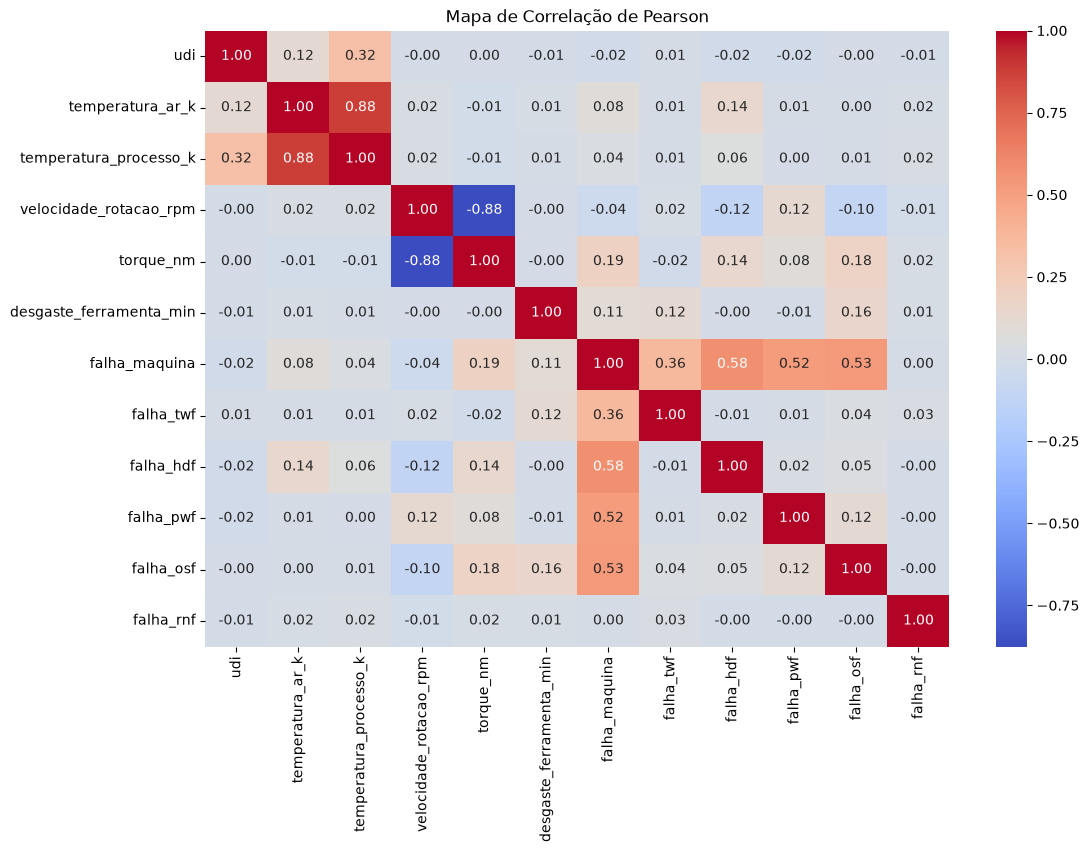

In [ ]:
#Função para gerar o gráfico de correlação entre as variáveis.

grafico_correlacao(df)

### Análise da correlação entre variáveis

O mapa de correlação de Pearson apresentou algumas relações relevantes entre as características do equipamento.

Foi identificada uma forte correlação positiva entre as variáveis `temperatura_ar_k` e `temperatura_processo_k`, indicando que ambas apresentam comportamento semelhante. Também foi observada uma forte correlação negativa entre `velocidade_rotacao_rpm` e `torque_nm`, demonstrando uma relação inversa entre essas características operacionais.

Em relação à variável alvo `falha_maquina`, as variáveis relacionadas aos tipos específicos de falha apresentaram maiores correlações, principalmente `falha_hdf`, `falha_osf` e `falha_pwf`.

Essas análises auxiliam na escolha das variáveis utilizadas nos modelos preditivos e indicam a necessidade de tratamento do desbalanceamento das classes antes do treinamento.

# Fase 2 - Limpeza e Tratamento de Dados (Data Prep)

Nesta etapa será realizado o tratamento da base de dados antes da construção dos modelos preditivos.

Serão executadas as seguintes ações:

- Identificação e remoção de registros duplicados;
- Análise dos valores ausentes;
- Imputação dos valores ausentes utilizando média ou mediana;
- Validação dos dados após o tratamento.

## Criação de uma cópia para tratamento

Para preservar o dataset original, será criada uma cópia antes da aplicação das transformações.

O dataset original será mantido para comparação, enquanto a versão tratada será utilizada nas próximas etapas do pipeline.

In [ ]:
# Criação de uma cópia para tratamento

df_tratamento = df.copy()

## Aplicação da limpeza e tratamento dos dados

A função de tratamento realiza:

- remoção de registros duplicados;
- identificação dos valores ausentes;
- preenchimento dos valores ausentes utilizando a mediana.

A mediana foi escolhida devido à presença de possíveis valores extremos identificados durante a análise exploratória.

In [ ]:
# Função para tratar os dados do dataset.

df_tratado, relatorio = tratar_dados(df_tratamento)


============================== RELATÓRIO DE TRATAMENTO DE DADOS ==============================
duplicados_encontrados: 0
duplicados_removidos: 0
valores_nulos_iniciais: {'temperatura_ar_k': 500, 'temperatura_processo_k': 500, 'velocidade_rotacao_rpm': 500, 'torque_nm': 500}
temperatura_ar_k_nulos_tratados: 500
temperatura_processo_k_nulos_tratados: 500
velocidade_rotacao_rpm_nulos_tratados: 500
torque_nm_nulos_tratados: 500
valores_nulos_finais: {}
registros_iniciais: 10000
registros_finais: 10000
registros_removidos_total: 0


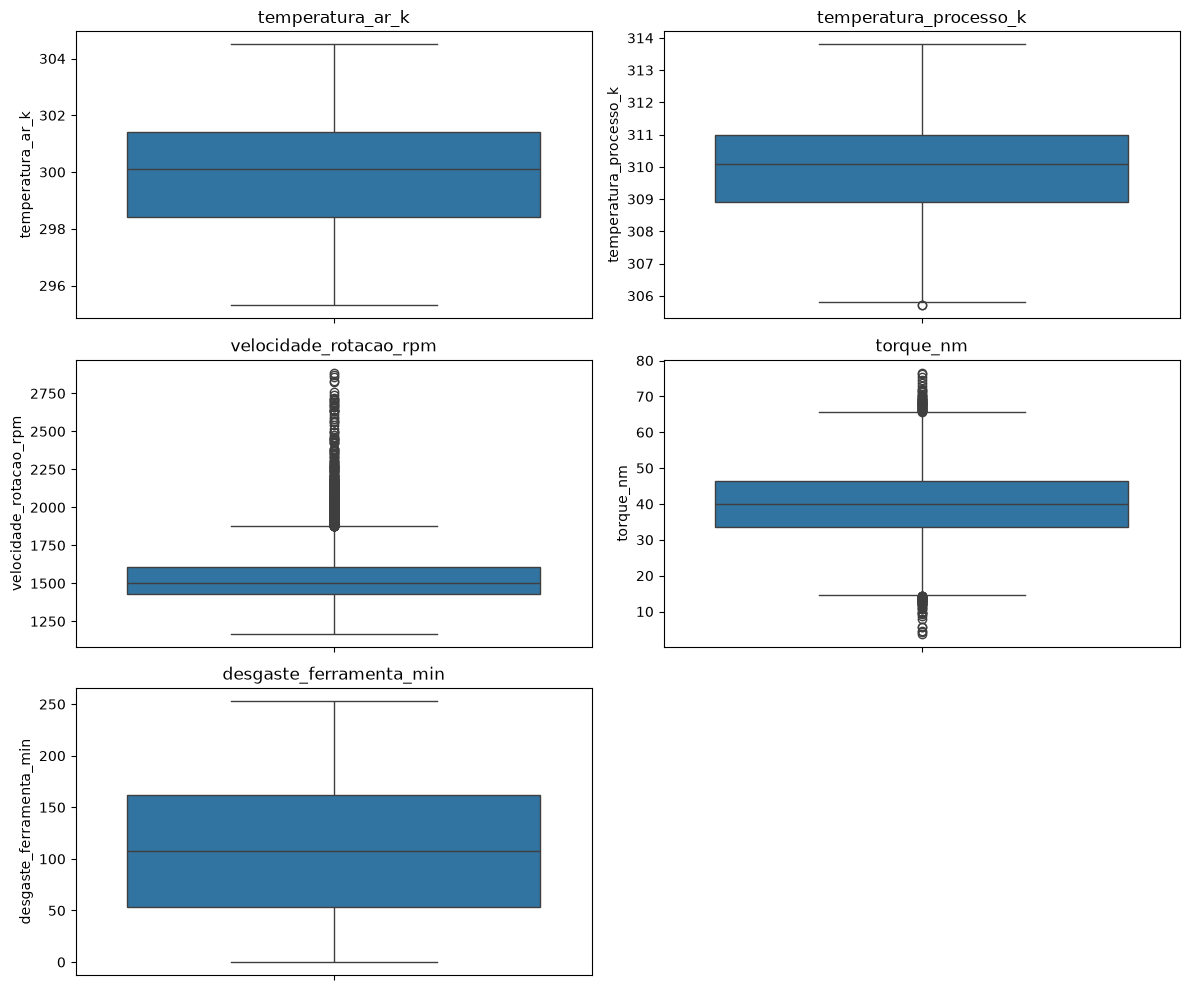

In [ ]:
# Função para gerar boxplots das variáveis do dataset.
gerar_boxplots(df_tratado)

### Análise dos Outliers

A análise dos boxplots permitiu identificar a presença de valores extremos em algumas variáveis relacionadas às condições operacionais dos equipamentos.

A variável `velocidade_rotacao_rpm` apresentou a maior concentração de outliers superiores, indicando registros com velocidades de rotação significativamente acima do comportamento predominante do conjunto de dados. Esses valores podem representar condições específicas de operação ou eventos atípicos durante o funcionamento dos equipamentos.

A variável `torque_nm` apresentou valores extremos tanto abaixo quanto acima dos limites esperados, indicando variações relevantes na aplicação de carga durante a operação das máquinas.

Por outro lado, as variáveis `temperatura_ar_k`, `temperatura_processo_k` e `desgaste_ferramenta_min` apresentaram distribuições mais estáveis, com baixa ocorrência de valores discrepantes.

A identificação desses comportamentos reforça a utilização da mediana como estratégia de imputação dos valores ausentes, pois essa medida estatística apresenta maior robustez em relação aos outliers quando comparada à média, evitando que valores extremos influenciem significativamente o preenchimento dos dados.

# Fase 3 - Feature Engineering

Nesta etapa será criada uma nova variável numérica a partir da combinação de variáveis existentes.

A nova variável representa uma característica derivada do funcionamento dos equipamentos, podendo auxiliar os modelos preditivos na identificação de padrões relacionados às falhas.

In [ ]:
# função para criar novas features a partir do dataset tratado.

df_features = criar_features(df_tratado)

# Verifica a estrutura do dataset de features.
df_features.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      10000 non-null  int64  
 1   id_produto               10000 non-null  str    
 2   tipo                     10000 non-null  str    
 3   temperatura_ar_k         10000 non-null  float64
 4   temperatura_processo_k   10000 non-null  float64
 5   velocidade_rotacao_rpm   10000 non-null  float64
 6   torque_nm                10000 non-null  float64
 7   desgaste_ferramenta_min  10000 non-null  int64  
 8   falha_maquina            10000 non-null  int64  
 9   falha_twf                10000 non-null  int64  
 10  falha_hdf                10000 non-null  int64  
 11  falha_pwf                10000 non-null  int64  
 12  falha_osf                10000 non-null  int64  
 13  falha_rnf                10000 non-null  int64  
 14  potencia                 10000 non

In [ ]:
# teste para verificar a descrição estatística da coluna potencia.
df_features["potencia"].describe()


count    10000.000000
mean     59970.673120
std       9951.344325
min      10966.800000
25%      53497.050000
50%      60310.400000
75%      66412.975000
max      99980.400000
Name: potencia, dtype: float64

In [ ]:
#Teste para verificar a quantidade de valores nulos na coluna potencia.

df_features["potencia"].isnull().sum()

np.int64(0)

## Validação da variável criada

Após a criação da variável `potencia`, foram realizadas validações para verificar sua consistência.

A nova coluna apresentou 10.000 registros preenchidos, mantendo a mesma quantidade de linhas do dataset original. Além disso, a análise estatística demonstrou uma variação significativa nos valores calculados, representando diferentes condições operacionais dos equipamentos.

A verificação de valores ausentes apresentou resultado igual a zero, confirmando que a operação matemática foi realizada sem gerar inconsistências nos dados.


# Fase 4 - Divisão e Balanceamento dos Dados

Nesta etapa será realizada a preparação dos dados para o treinamento dos modelos de Machine Learning.

As variáveis preditoras serão separadas da variável alvo, representada pela ocorrência de falha da máquina. Em seguida, os dados serão divididos em conjuntos de treino e teste, mantendo a proporção das classes através da utilização do parâmetro `stratify=y`.

Após a divisão, será aplicada uma técnica de balanceamento somente nos dados de treino, evitando o vazamento de informações entre os conjuntos e garantindo que os modelos sejam treinados com uma distribuição adequada das classes.

In [13]:
# Função para separar as variáveis independentes (X) e a variável dependente (y).

X, y = separar_variaveis(df_features)


In [14]:
# Teste para verifica as colunas que ficaram no eixo x.

X.columns

Index(['udi', 'id_produto', 'tipo', 'temperatura_ar_k',
       'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm',
       'desgaste_ferramenta_min', 'potencia'],
      dtype='str')

In [15]:
# Teste para verificar as colunas que ficaram no eixo y.

y.head()

0    0
1    0
2    0
3    0
4    0
Name: falha_maquina, dtype: int64

In [16]:
# Teste para verificar quantidade de registros dos eixos x e y.

print("X:", X.shape)
print("y:", y.shape)

X: (10000, 9)
y: (10000,)


In [ ]:
# Função para preparar as variáveis categóricas do dataset.

X = preparar_variaveis_categoricas(X)

In [ ]:
#Teste para verificar a estrutura do dataset após o tratamento das variáveis categóricas.

X.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      10000 non-null  int64  
 1   temperatura_ar_k         10000 non-null  float64
 2   temperatura_processo_k   10000 non-null  float64
 3   velocidade_rotacao_rpm   10000 non-null  float64
 4   torque_nm                10000 non-null  float64
 5   desgaste_ferramenta_min  10000 non-null  int64  
 6   potencia                 10000 non-null  float64
 7   tipo_L                   10000 non-null  int64  
 8   tipo_M                   10000 non-null  int64  
dtypes: float64(5), int64(4)
memory usage: 703.3 KB


In [ ]:
#Função para dividir os dados em conjuntos de treino e teste.

X_train, X_test, y_train, y_test = dividir_dados(X, y)

In [ ]:
#Teste para verificar a quantidade de registros nos conjuntos de treino e teste.

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 9)
X_test: (2000, 9)
y_train: (8000,)
y_test: (2000,)


In [ ]:
#Teste para verificar a distribuição das classes nos conjuntos de treino e teste.
print(y.value_counts(normalize=True))
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

falha_maquina
0    0.9661
1    0.0339
Name: proportion, dtype: float64
falha_maquina
0    0.966125
1    0.033875
Name: proportion, dtype: float64
falha_maquina
0    0.966
1    0.034
Name: proportion, dtype: float64


In [ ]:
#Função para aplicar o SMOTE e balancear as classes do conjunto de treino.

X_train_balanceado, y_train_balanceado = aplicar_smote(
    X_train,
    y_train
)

In [ ]:
#Teste para verificar a distribuição das classes no conjunto de treino balanceado.
print(y_train_balanceado.value_counts())

falha_maquina
0    7729
1    7729
Name: count, dtype: int64


## Validação da Divisão e Balanceamento dos Dados

Após a separação das variáveis preditoras e da variável alvo, foram realizadas validações para garantir a correta preparação dos dados para o treinamento dos modelos.

A divisão dos dados resultou em 8.000 registros para treinamento e 2.000 registros para teste, mantendo a proporção de 80% e 20% conforme definido no pipeline. A utilização do parâmetro `stratify=y` garantiu que a distribuição das classes de falha permanecesse equivalente entre os conjuntos de treino e teste.

A análise da proporção das classes confirmou a presença de um desbalanceamento significativo na variável alvo `falha_maquina`, com predominância de registros sem falha em relação aos registros de falha.

Para corrigir esse desbalanceamento, foi aplicada a técnica de SMOTE exclusivamente nos dados de treinamento, evitando o vazamento de informações entre os conjuntos. Dessa forma, o modelo poderá aprender os padrões da classe minoritária sem comprometer a avaliação realizada posteriormente com os dados de teste.